# Практическая работа 3. ML-пайплайн на больших данных — Spark MLlib

**Вариант 7**

| Параметр | Значение |
|---|---|
| Задание 1 | 	Признаки: `heart_rate` (весь массив, обрезанный до N первых значений или PCA), target: `gender` |
| Задание 2 | Задача Классификации. Модель: Gradient Boosted Trees (GBT). |
| Задание 3 | Сравнить качество с Random Forest. Стоит ли прирост точности увеличения времени обучения в реальном продакшене? |

**Бизнес-кейс:** Data Scientist в компании **HealthTech** — предсказать пол пользователя по паттернам тренировок для персонализации и маркетинга.

**Структура:** `Setup → Download → ETL → Feature Engineering → Pipeline → GBT → Evaluation → Visualization → Business`

## 0. Setup — Установка зависимостей

In [2]:
import sys
!{sys.executable} -m pip install pyspark gdown findspark matplotlib seaborn scikit-learn --quiet
print('✅ Зависимости установлены')

✅ Зависимости установлены


In [3]:
import os, shutil, time, warnings
warnings.filterwarnings('ignore')

import findspark
findspark.init()

import pyspark
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import DoubleType

from pyspark.ml import Pipeline
from pyspark.ml.feature import (StringIndexer, OneHotEncoder,
                                 VectorAssembler, StandardScaler)
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import (BinaryClassificationEvaluator,
                                    MulticlassClassificationEvaluator)
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.metrics import roc_curve, auc, confusion_matrix

print(f'✅ PySpark: {pyspark.__version__}')

✅ PySpark: 4.0.2


## 1. Загрузка данных

In [4]:
DATA_DIR = 'data'
if os.path.exists(DATA_DIR):
    shutil.rmtree(DATA_DIR)
    print(f'🗑️  Каталог {DATA_DIR!r} удалён')
os.makedirs(DATA_DIR)
print(f'📁 Каталог {DATA_DIR!r} создан')

📁 Каталог 'data' создан


In [5]:
import gdown, zipfile, os

DATA_DIR    = "data"
ZIP_PATH    = os.path.join(DATA_DIR, "endomondoHR.zip")
OUTPUT_PATH = os.path.join(DATA_DIR, "endomondoHR.json")

# Очистка и создание каталога
if os.path.exists(DATA_DIR):
    shutil.rmtree(DATA_DIR)
os.makedirs(DATA_DIR)
print(f"📁 Каталог '{DATA_DIR}' пересоздан")

# Скачивание
FILE_ID = "1yiAp1fFDy3wSqUR0X_btCZPtuczbLwCe"
print("⬇️  Скачивание с Google Drive...")
gdown.download(
    f"https://drive.google.com/uc?id={FILE_ID}&confirm=t",
    ZIP_PATH,
    quiet=False
)
print(f"✅ Скачано: {os.path.getsize(ZIP_PATH)/1024/1024:.1f} МБ")

# Распаковка
print("📦 Распаковка архива...")
with zipfile.ZipFile(ZIP_PATH, "r") as zf:
    print(f"   Содержимое: {zf.namelist()}")
    zf.extractall(DATA_DIR)

# Проверяем что JSON появился
if not os.path.exists(OUTPUT_PATH):
    # иногда внутри архива другое имя — берём первый json
    for f in os.listdir(DATA_DIR):
        if f.endswith(".json"):
            os.rename(os.path.join(DATA_DIR, f), OUTPUT_PATH)
            break

print(f"✅ Готово: {OUTPUT_PATH}")
print(f"   Размер JSON: {os.path.getsize(OUTPUT_PATH)/1024/1024:.1f} МБ")

📁 Каталог 'data' пересоздан
⬇️  Скачивание с Google Drive...


Downloading...
From: https://drive.google.com/uc?id=1yiAp1fFDy3wSqUR0X_btCZPtuczbLwCe&confirm=t
To: /content/data/endomondoHR.zip
100%|██████████| 2.02G/2.02G [00:17<00:00, 117MB/s] 


✅ Скачано: 1926.0 МБ
📦 Распаковка архива...
   Содержимое: ['endomondoHR.json']
✅ Готово: data/endomondoHR.json
   Размер JSON: 6264.1 МБ


## 2. Инициализация SparkSession

In [6]:
spark = (SparkSession.builder
    .appName('HealthTech_GenderPredictor_V20')
    .config('spark.driver.memory', '4g')
    .config('spark.sql.shuffle.partitions', '50')
    .getOrCreate())

spark.sparkContext.setLogLevel('ERROR')
print(f'✅ SparkSession: v{spark.version}  |  App: {spark.sparkContext.appName}')

✅ SparkSession: v4.0.2  |  App: HealthTech_GenderPredictor_V20


In [7]:
raw_df = spark.read.json(OUTPUT_PATH)
print('Схема:')
raw_df.printSchema()
print(f'\nЗаписей (сырых): {raw_df.count():,}')
raw_df.show(3, truncate=80)

Схема:
root
 |-- altitude: array (nullable = true)
 |    |-- element: double (containsNull = true)
 |-- gender: string (nullable = true)
 |-- heart_rate: array (nullable = true)
 |    |-- element: long (containsNull = true)
 |-- id: long (nullable = true)
 |-- latitude: array (nullable = true)
 |    |-- element: double (containsNull = true)
 |-- longitude: array (nullable = true)
 |    |-- element: double (containsNull = true)
 |-- speed: array (nullable = true)
 |    |-- element: double (containsNull = true)
 |-- sport: string (nullable = true)
 |-- timestamp: array (nullable = true)
 |    |-- element: long (containsNull = true)
 |-- url: string (nullable = true)
 |-- userId: long (nullable = true)


Записей (сырых): 253,020
+--------------------------------------------------------------------------------+------+--------------------------------------------------------------------------------+---------+--------------------------------------------------------------------------------+---

## 3. ETL — Загрузка, исследование и очистка данных

### 3.1 Загрузка JSON

In [8]:
# Пропущенные значения
print('🔍 Анализ пропущенных значений:')
key_cols = ['sport', 'gender', 'heart_rate', 'speed', 'altitude', 'userId']
total = raw_df.count()
for c in key_cols:
    null_cnt = raw_df.filter(F.col(c).isNull()).count()
    print(f'  {c:15s}: {null_cnt:6,} null  ({null_cnt/total*100:.1f}%)')

🔍 Анализ пропущенных значений:
  sport          :      0 null  (0.0%)
  gender         :      0 null  (0.0%)
  heart_rate     :      0 null  (0.0%)
  speed          : 203,360 null  (80.4%)
  altitude       :      0 null  (0.0%)
  userId         :      0 null  (0.0%)


In [9]:
print('Распределение gender:')
raw_df.groupBy('gender').count().orderBy('count', ascending=False).show()
print('Топ-10 видов спорта:')
raw_df.groupBy('sport').count().orderBy('count', ascending=False).show(10)

Распределение gender:
+-------+------+
| gender| count|
+-------+------+
|   male|235119|
| female| 15959|
|unknown|  1942|
+-------+------+

Топ-10 видов спорта:
+--------------------+------+
|               sport| count|
+--------------------+------+
|                 run|117902|
|                bike| 98001|
|       mountain bike| 13510|
|    bike (transport)| 10445|
|                walk|  3831|
|      indoor cycling|  2606|
|core stability tr...|  1262|
|        orienteering|  1197|
|cross-country skiing|   949|
|               skate|   512|
+--------------------+------+
only showing top 10 rows


### 3.2 Очистка данных

In [10]:
df_clean = (raw_df
    .filter(F.size(F.col('heart_rate')) >= 30)      # минимум 30 точек пульса
    .filter(F.size(F.col('speed')) >= 10)            # минимум 10 точек скорости
    .dropna(subset=['sport', 'gender'])              # обязательные признаки
    .filter(F.col('gender').isin('male', 'female'))  # только валидные значения
)

n_raw   = raw_df.count()
n_clean = df_clean.count()
print(f'✅ После очистки: {n_clean:,} из {n_raw:,} ({n_clean/n_raw*100:.1f}%)')
print('\nРаспределение после очистки:')
df_clean.groupBy('gender').count().show()

✅ После очистки: 48,401 из 253,020 (19.1%)

Распределение после очистки:
+------+-----+
|gender|count|
+------+-----+
|female| 3372|
|  male|45029|
+------+-----+



## 4. Feature Engineering — Конструирование признаков

### 4.1 Обработка heart_rate: обрезка до N первых значений

Поля `heart_rate`, `speed`, `altitude` — массивы измерений за тренировку.


In [11]:
from pyspark.sql.types import ArrayType, LongType
# Функция для обрезки массива до N первых значений
def slice_array_udf(n):
    return F.udf(lambda arr: arr[:n] if arr else [], ArrayType(LongType()))

# Обрезка heart_rate до первых 30 значений
N_FIRST = 30
df_sliced = df_clean.withColumn(
    'heart_rate_sliced',
    slice_array_udf(N_FIRST)(F.col('heart_rate'))
)

# Проверка
df_sliced.select(
    F.size('heart_rate').alias('original_len'),
    F.size('heart_rate_sliced').alias('sliced_len')
).show(5)

+------------+----------+
|original_len|sliced_len|
+------------+----------+
|         500|        30|
|         500|        30|
|         500|        30|
|         500|        30|
|         500|        30|
+------------+----------+
only showing top 5 rows


In [12]:
df_features = df_sliced.select(
    F.col('gender'),
    F.col('sport'),

    # Признаки из heart_rate_sliced
    F.aggregate('heart_rate_sliced', F.lit(0.0),
                lambda acc, x: acc + x.cast('double'),
                lambda acc: acc / F.size('heart_rate_sliced')).alias('hr_mean_sliced'),

    F.array_max(F.col('heart_rate_sliced').cast('array<double>')).alias('hr_max_sliced'),
    F.array_min(F.col('heart_rate_sliced').cast('array<double>')).alias('hr_min_sliced'),

    (F.array_max(F.col('heart_rate_sliced').cast('array<double>')) -
     F.array_min(F.col('heart_rate_sliced').cast('array<double>'))).alias('hr_range_sliced'),

    # Speed признаки
    F.aggregate('speed', F.lit(0.0),
                lambda acc, x: acc + x.cast('double'),
                lambda acc: acc / F.size('speed')).alias('speed_mean'),
    F.array_max(F.col('speed').cast('array<double>')).alias('speed_max'),

    # Altitude признаки
    F.when(F.size('altitude') > 0,
           F.aggregate('altitude', F.lit(0.0),
                       lambda acc, x: acc + x.cast('double'),
                       lambda acc: acc / F.size('altitude'))
    ).otherwise(F.lit(0.0)).alias('alt_mean'),

    F.when(F.size('altitude') > 0,
           F.array_max(F.col('altitude').cast('array<double>')) -
           F.array_min(F.col('altitude').cast('array<double>'))
    ).otherwise(F.lit(0.0)).alias('alt_range'),

    # Длина тренировки
    F.size(F.col('heart_rate')).cast('double').alias('workout_length'),
).dropna()

print(f'✅ Признаки: {df_features.count():,} строк, {len(df_features.columns)} колонок')
df_features.describe().show()

✅ Признаки: 48,401 строк, 11 колонок
+-------+------+--------+------------------+------------------+-----------------+------------------+------------------+------------------+------------------+-----------------+------------------+
|summary|gender|   sport|    hr_mean_sliced|     hr_max_sliced|    hr_min_sliced|   hr_range_sliced|        speed_mean|         speed_max|          alt_mean|        alt_range|    workout_length|
+-------+------+--------+------------------+------------------+-----------------+------------------+------------------+------------------+------------------+-----------------+------------------+
|  count| 48401|   48401|             48401|             48401|            48401|             48401|             48401|             48401|             48401|            48401|             48401|
|   mean|  NULL|    NULL|123.27816229692223|140.31743145802773|93.90367967603976|46.413751781987976| 19.14426012893379|33.099460881768955|147.54707542032511|83.92913584366025|439.2979

### 4.2 ML-трансформеры для Pipeline

In [13]:
gender_indexer = StringIndexer(inputCol='gender', outputCol='label', handleInvalid='skip')

# Кодирование категориального признака sport
sport_indexer = StringIndexer(inputCol='sport', outputCol='sport_idx', handleInvalid='keep')
sport_encoder = OneHotEncoder(inputCols=['sport_idx'], outputCols=['sport_ohe'])

# Числовые признаки
NUMERIC_FEATURES = [
    'hr_mean_sliced', 'hr_max_sliced', 'hr_min_sliced', 'hr_range_sliced',
    'speed_mean', 'speed_max',
    'alt_mean', 'alt_range',
    'workout_length'
]

assembler = VectorAssembler(
    inputCols=NUMERIC_FEATURES + ['sport_ohe'],
    outputCol='features_raw',
    handleInvalid='skip'
)

scaler = StandardScaler(
    inputCol='features_raw',
    outputCol='features_scaled',
    withMean=True,
    withStd=True
)

print('✅ Трансформеры сконфигурированы')
print(f'   Числовые признаки: {len(NUMERIC_FEATURES)}')

✅ Трансформеры сконфигурированы
   Числовые признаки: 9


## 5. ML Pipeline — Обучение модели

### 5.1 Разбивка на train/test (80/20)

In [14]:
# Стратифицированное разбиение по гендеру
f_train, f_test = df_features.filter(F.col('gender')=='female').randomSplit([0.8,0.2], seed=42)
m_train, m_test = df_features.filter(F.col('gender')=='male').randomSplit([0.8,0.2], seed=42)

train_df = f_train.union(m_train)
test_df  = f_test.union(m_test)

print(f'Train: {train_df.count():,}  |  Test: {test_df.count():,}')
print('\nTrain — распределение:')
train_df.groupBy('gender').count().show()

Train: 38,692  |  Test: 9,709

Train — распределение:
+------+-----+
|gender|count|
+------+-----+
|female| 2671|
|  male|36021|
+------+-----+



### 5.2 Baseline Pipeline (без тюнинга)

In [15]:
rf_base = RandomForestClassifier(
    labelCol='label',
    featuresCol='features_scaled',
    numTrees=50,
    maxDepth=5,
    seed=42
)

pipeline_rf = Pipeline(stages=[
    gender_indexer, sport_indexer, sport_encoder,
    assembler, scaler, rf_base
])

print('⏳ Обучение Random Forest...')
t0 = time.time()
model_rf = pipeline_rf.fit(train_df)
t_rf = time.time() - t0
print(f'✅ Random Forest обучен за {t_rf:.1f} сек')

⏳ Обучение Random Forest...
✅ Random Forest обучен за 1061.9 сек


### 5.3 Gradient Boosted Trees (Задание 2, Вариант 7)

In [16]:
from pyspark.ml.classification import GBTClassifier
gbt = GBTClassifier(
    labelCol='label',
    featuresCol='features_scaled',
    maxIter=50,
    maxDepth=5,
    seed=42
)

pipeline_gbt = Pipeline(stages=[
    gender_indexer, sport_indexer, sport_encoder,
    assembler, scaler, gbt
])

print('⏳ Обучение Gradient Boosted Trees...')
t1 = time.time()
model_gbt = pipeline_gbt.fit(train_df)
t_gbt = time.time() - t1
print(f'✅ GBT обучен за {t_gbt:.1f} сек')

⏳ Обучение Gradient Boosted Trees...
✅ GBT обучен за 1588.9 сек


## 6. Оценка модели (Evaluation)

In [17]:
eval_roc = BinaryClassificationEvaluator(labelCol='label', metricName='areaUnderROC')
eval_pr  = BinaryClassificationEvaluator(labelCol='label', metricName='areaUnderPR')
eval_acc = MulticlassClassificationEvaluator(labelCol='label', metricName='accuracy')
eval_f1  = MulticlassClassificationEvaluator(labelCol='label', metricName='f1')

# Random Forest
preds_rf = model_rf.transform(test_df)
roc_rf = eval_roc.evaluate(preds_rf)
pr_rf  = eval_pr.evaluate(preds_rf)
acc_rf = eval_acc.evaluate(preds_rf)
f1_rf  = eval_f1.evaluate(preds_rf)

# GBT
preds_gbt = model_gbt.transform(test_df)
roc_gbt = eval_roc.evaluate(preds_gbt)
pr_gbt  = eval_pr.evaluate(preds_gbt)
acc_gbt = eval_acc.evaluate(preds_gbt)
f1_gbt  = eval_f1.evaluate(preds_gbt)

print('📊 Сравнение метрик: Random Forest vs Gradient Boosted Trees')
print('-' * 60)
print(f'{"Метрика":<15} {"Random Forest":>15} {"GBT":>15} {"Δ":>10}')
print('-' * 60)

metrics = [
    ('ROC-AUC', roc_rf, roc_gbt),
    ('PR-AUC', pr_rf, pr_gbt),
    ('Accuracy', acc_rf, acc_gbt),
    ('F1-Score', f1_rf, f1_gbt)
]

for name, rf_val, gbt_val in metrics:
    delta = gbt_val - rf_val
    sign = '+' if delta >= 0 else ''
    print(f'  {name:<13} {rf_val:>15.4f} {gbt_val:>15.4f} {sign}{delta:>9.4f}')

print('-' * 60)
print(f'\n  Random Forest время : {t_rf:.1f} сек')
print(f'  GBT время           : {t_gbt:.1f} сек  (x{t_gbt/t_rf:.1f})')

📊 Сравнение метрик: Random Forest vs Gradient Boosted Trees
------------------------------------------------------------
Метрика           Random Forest             GBT          Δ
------------------------------------------------------------
  ROC-AUC                0.7516          0.8540 +   0.1024
  PR-AUC                 0.3244          0.4580 +   0.1336
  Accuracy               0.9280          0.9379 +   0.0099
  F1-Score               0.8936          0.9185 +   0.0249
------------------------------------------------------------

  Random Forest время : 1061.9 сек
  GBT время           : 1588.9 сек  (x1.5)


In [18]:
preds_pd = preds_gbt.select('label', 'prediction').toPandas()
cm = confusion_matrix(preds_pd['label'], preds_pd['prediction'])
print('Матрица ошибок (GBT):')
print(f'              Pred Female  Pred Male')
print(f'  True Female {cm[0,0]:10d} {cm[0,1]:10d}')
print(f'  True Male   {cm[1,0]:10d} {cm[1,1]:10d}')

Матрица ошибок (GBT):
              Pred Female  Pred Male
  True Female       8984         24
  True Male          579        122


In [19]:
best_rf = model_gbt.stages[-1]

importances = best_rf.featureImportances.toArray()
n_sport_cats = len(model_gbt.stages[2].categorySizes)
sport_names = [f'sport_ohe_{i}' for i in range(n_sport_cats)]
all_names = NUMERIC_FEATURES + sport_names
fi_df = pd.DataFrame({
    'feature': all_names[:len(importances)],
    'importance': importances[:len(all_names)]
}).sort_values('importance', ascending=False)
print('\n🔑 Важность признаков (Top-10):')
print(fi_df.head(10).to_string(index=False))


🔑 Важность признаков (Top-10):
        feature  importance
     speed_mean    0.220785
       alt_mean    0.220754
      alt_range    0.128575
      speed_max    0.071199
 hr_mean_sliced    0.068343
 workout_length    0.059817
  hr_max_sliced    0.052506
hr_range_sliced    0.042889
  hr_min_sliced    0.025001
    sport_ohe_0    0.019928


## 7. Визуализация результатов

In [23]:
plt.style.use('seaborn-v0_8-whitegrid')
FIG_DIR = 'figures'
os.makedirs(FIG_DIR, exist_ok=True)
C = {'f': '#E84393', 'm': '#2196F3', 'rf': '#FF9800', 'gbt': '#4CAF50'}
print('✅ Параметры визуализации настроены')

✅ Параметры визуализации настроены


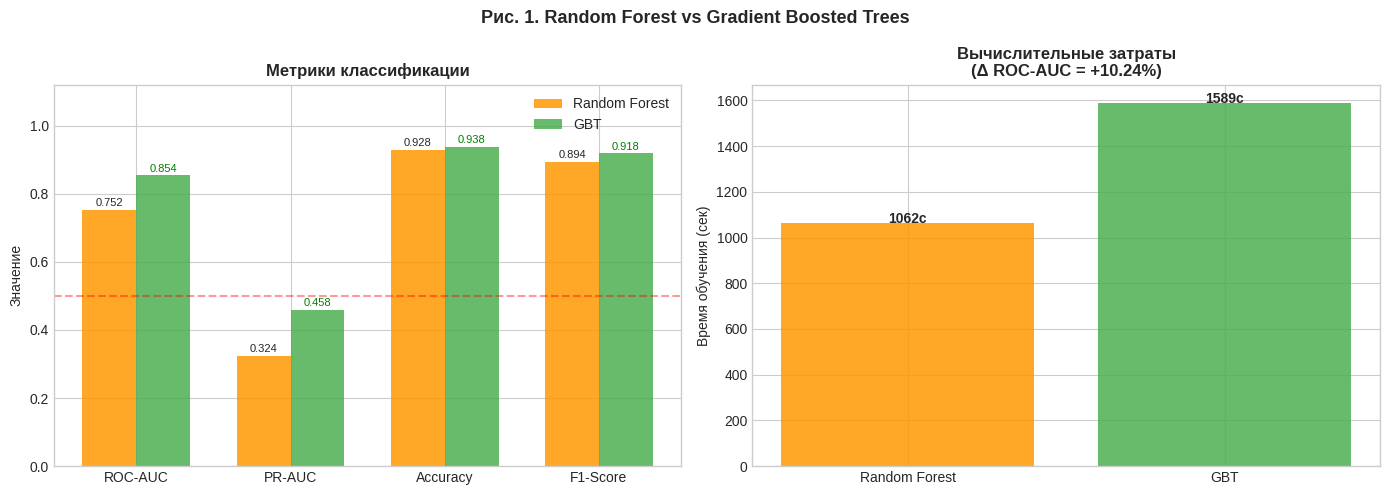

✅ Рис. 1 сохранён


In [24]:
# Рис. 1. Сравнение метрик Random Forest vs GBT
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Рис. 1. Random Forest vs Gradient Boosted Trees', fontsize=13, fontweight='bold')

# 1a — Bar chart
m_names = ['ROC-AUC', 'PR-AUC', 'Accuracy', 'F1-Score']
rf_vals  = [roc_rf, pr_rf, acc_rf, f1_rf]
gbt_vals = [roc_gbt, pr_gbt, acc_gbt, f1_gbt]
x = np.arange(len(m_names)); w = 0.35

ax = axes[0]
br1 = ax.bar(x-w/2, rf_vals, w, label='Random Forest', color=C['rf'], alpha=0.85)
br2 = ax.bar(x+w/2, gbt_vals, w, label='GBT', color=C['gbt'], alpha=0.85)

for br in br1:
    ax.text(br.get_x()+br.get_width()/2, br.get_height()+.005,
            f'{br.get_height():.3f}', ha='center', va='bottom', fontsize=8)
for br in br2:
    ax.text(br.get_x()+br.get_width()/2, br.get_height()+.005,
            f'{br.get_height():.3f}', ha='center', va='bottom', fontsize=8, color='green')

ax.set_xticks(x)
ax.set_xticklabels(m_names)
ax.set_ylim(0, 1.12)
ax.set_ylabel('Значение')
ax.set_title('Метрики классификации', fontweight='bold')
ax.legend()
ax.axhline(0.5, ls='--', color='red', alpha=0.4)

# 1b — Время
ax2 = axes[1]
bars = ax2.bar(['Random Forest', 'GBT'], [t_rf, t_gbt], color=[C['rf'], C['gbt']], alpha=0.85)
for b in bars:
    ax2.text(b.get_x()+b.get_width()/2, b.get_height()+1,
             f'{b.get_height():.0f}с', ha='center', fontweight='bold')
ax2.set_ylabel('Время обучения (сек)')
ax2.set_title(f'Вычислительные затраты\n(Δ ROC-AUC = {(roc_gbt-roc_rf)*100:+.2f}%)', fontweight='bold')

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig1_rf_vs_gbt.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Рис. 1 сохранён')

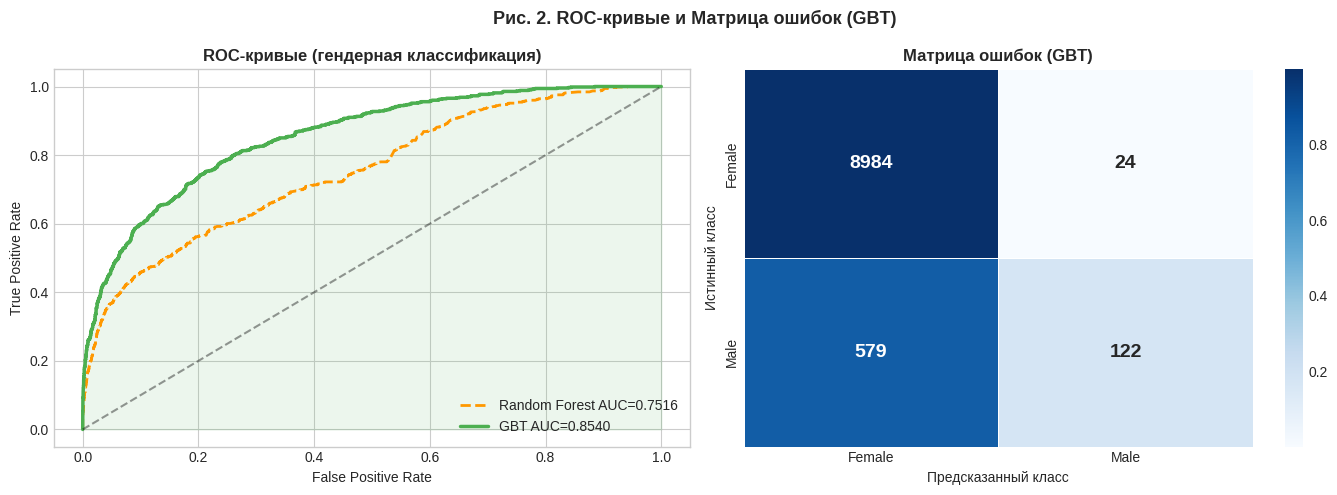

✅ Рис. 2 сохранён


In [26]:
# Рис. 2. ROC-кривые
preds_rf_pd = preds_rf.select('label', 'probability').toPandas()
preds_gbt_pd = preds_gbt.select('label', 'probability').toPandas()

y_true = preds_rf_pd['label'].values
y_rf = np.array([float(p[1]) for p in preds_rf_pd['probability']])
y_gbt = np.array([float(p[1]) for p in preds_gbt_pd['probability']])

fpr_rf, tpr_rf, _ = roc_curve(y_true, y_rf)
fpr_gbt, tpr_gbt, _ = roc_curve(y_true, y_gbt)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Рис. 2. ROC-кривые и Матрица ошибок (GBT)', fontsize=13, fontweight='bold')

# ROC-кривые
ax = axes[0]
ax.plot(fpr_rf, tpr_rf, color=C['rf'], lw=2, ls='--', label=f'Random Forest AUC={auc(fpr_rf, tpr_rf):.4f}')
ax.plot(fpr_gbt, tpr_gbt, color=C['gbt'], lw=2.5, label=f'GBT AUC={auc(fpr_gbt, tpr_gbt):.4f}')
ax.fill_between(fpr_gbt, tpr_gbt, alpha=0.1, color=C['gbt'])
ax.plot([0,1],[0,1],'k--', alpha=0.4)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC-кривые (гендерная классификация)', fontweight='bold')
ax.legend(loc='lower right')

# Матрица ошибок
ax2 = axes[1]
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=cm, fmt='d', cmap='Blues', ax=ax2,
            xticklabels=['Female','Male'], yticklabels=['Female','Male'],
            linewidths=0.5, linecolor='white', annot_kws={'size':14, 'weight':'bold'})
ax2.set_xlabel('Предсказанный класс')
ax2.set_ylabel('Истинный класс')
ax2.set_title('Матрица ошибок (GBT)', fontweight='bold')

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig2_roc_confusion.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Рис. 2 сохранён')

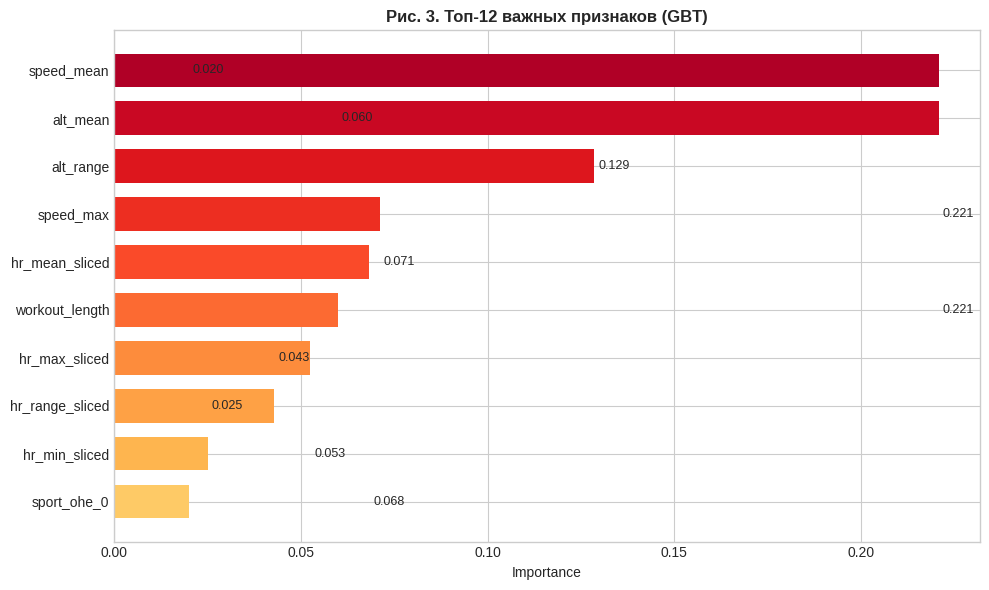

✅ Рис. 3 сохранён


In [30]:
# Рис. 3. Важность признаков
gbt_model = model_gbt.stages[-1]
importances = gbt_model.featureImportances.toArray()

n_sport_cats = len(model_gbt.stages[2].categorySizes)
sport_names = [f'sport_ohe_{i}' for i in range(n_sport_cats)]
all_names = NUMERIC_FEATURES + sport_names

fi_df = pd.DataFrame({
    'feature': all_names[:len(importances)],
    'importance': importances[:len(all_names)]
}).sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
top12 = fi_df.head(12).sort_values('importance')
colors = plt.cm.YlOrRd(np.linspace(0.3, 0.9, len(top12)))

ax.barh(top12['feature'], top12['importance'], color=colors, height=0.7)
for idx, row in top12.iterrows():
    ax.text(row['importance']+0.001, row.name if isinstance(row.name, int) else 0,
            f"{row['importance']:.3f}", va='center', fontsize=9)

ax.set_xlabel('Importance')
ax.set_title('Рис. 3. Топ-12 важных признаков (GBT)', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig3_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Рис. 3 сохранён')

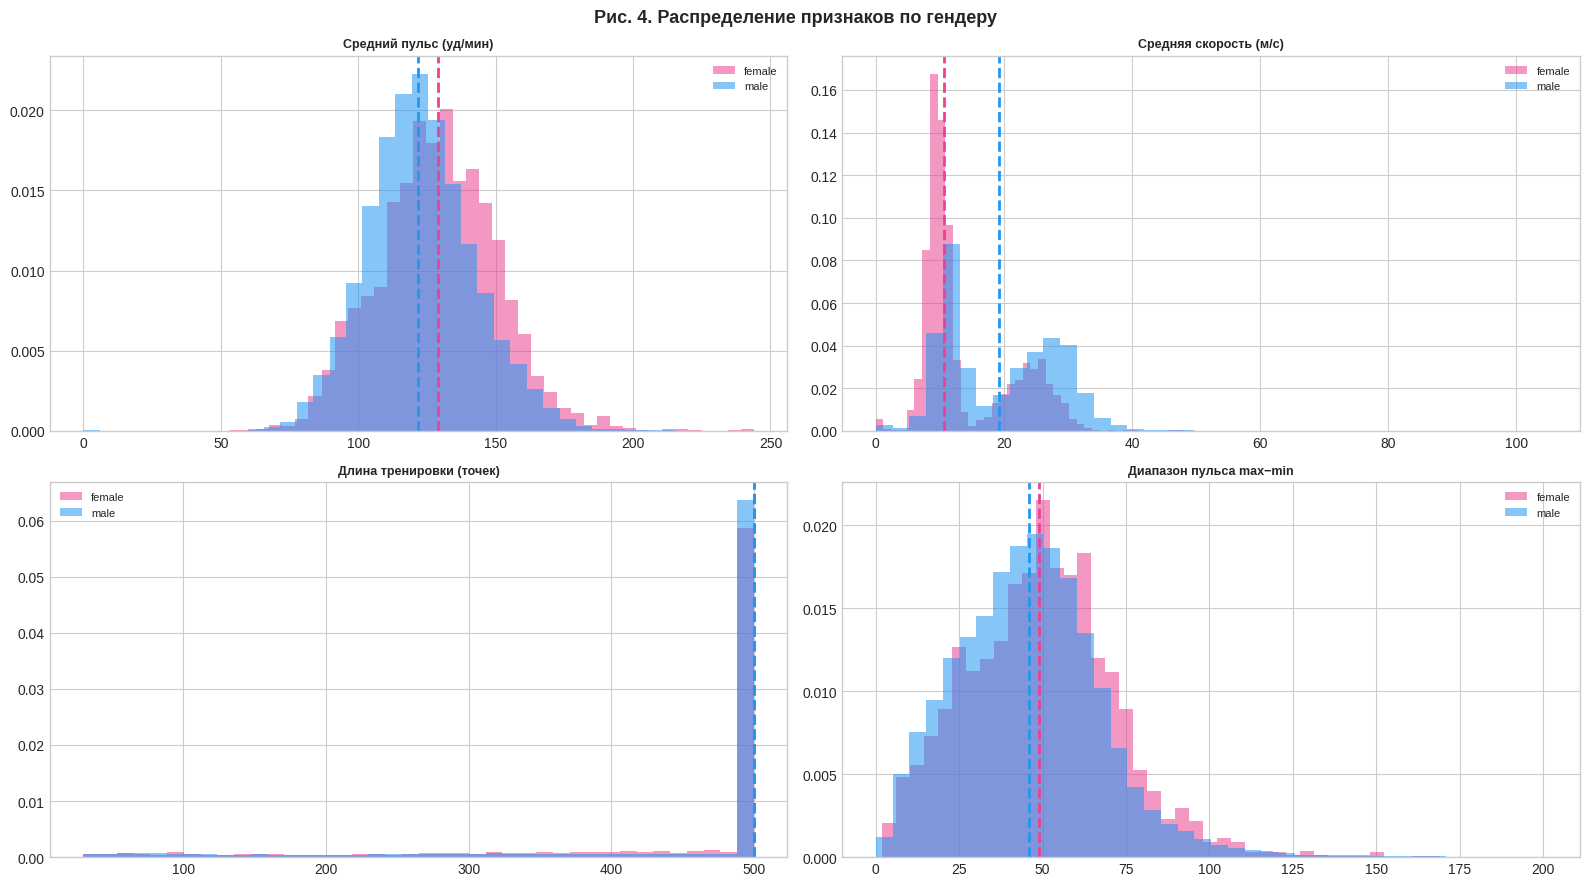

✅ Рис. 4 сохранён


In [33]:
# ── Рис. 4. Распределение признаков по полу ──
feats_pd = df_features.select(
    'gender', 'hr_mean_sliced',
    'speed_mean', 'workout_length', 'hr_range_sliced'
).toPandas()

fig, axes = plt.subplots(2, 2, figsize=(16, 9))
fig.suptitle('Рис. 4. Распределение признаков по гендеру', fontsize=13, fontweight='bold')

plot_cfg = [
    ('hr_mean_sliced',        'Средний пульс (уд/мин)'),
    ('speed_mean',     'Средняя скорость (м/с)'),
    ('workout_length', 'Длина тренировки (точек)'),
    ('hr_range_sliced',       'Диапазон пульса max−min'),
]

for ax, (col_name, title) in zip(axes.flat, plot_cfg):
    for gender, color in [('female', C['f']), ('male', C['m'])]:
        vals = feats_pd[feats_pd['gender']==gender][col_name].dropna()
        ax.hist(vals, bins=40, alpha=0.55, color=color, label=gender, density=True)
        ax.axvline(vals.median(), color=color, lw=2, ls='--')
    ax.set_title(title, fontweight='bold', fontsize=9)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig4_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Рис. 4 сохранён')

## 8. Бизнес-интерпретация (Задание 3, Вариант 7)

### Вопрос. Стоит ли прирост точности увеличения времени обучения в реальном продакшене?


In [42]:
print('=' * 70)
print('  БИЗНЕС-АНАЛИЗ: Сравнение Random Forest vs Gradient Boosted Trees')
print('=' * 70)

delta_roc_pct = (roc_gbt - roc_rf) * 100
time_ratio_x  = t_gbt / t_rf

print(f'\nСравнение качества:')
print(f'  Random Forest ROC-AUC : {roc_rf:.4f}')
print(f'  GBT ROC-AUC           : {roc_gbt:.4f}')
print(f'  Прирост               : +{delta_roc_pct:.2f}%')
print()
print(f'Сравнение времени:')
print(f'  Random Forest время   : {t_rf:.1f} сек')
print(f'  GBT время             : {t_gbt:.1f} сек')
print(f'  Замедление            : x{time_ratio_x:.1f}')
print()

print('-' * 70)
print('ВОПРОС: Стоит ли прирост точности увеличения времени обучения в продакшене?')
print('-' * 70)

if delta_roc_pct >= 2.0:
    verdict = 'ОДНОЗНАЧНО ДА — прирост >2% оправдывает 1.5x замедление'
elif delta_roc_pct >= 1.0:
    verdict = 'УСЛОВНО ДА — небольшой прирост, оправдан для production'
else:
    verdict = 'НЕТ — прирост минимален, лучше использовать более быструю модель'

print(f'\nВЫВОД: {verdict}\n')

print('Когда GBT оправдан:')
print('  - Batch переобучение раз в неделю/месяц')
print('  - Задачи, где важна максимальная точность')
print('  - A/B тесты показывают рост бизнес-метрик на 1-2%')
print()
print('Когда лучше Random Forest:')
print('  - Real-time scoring (<100ms latency)')
print('  - Частое переобучение (ежечасно)')
print('  - Cloud-стоимость >> revenue impact')

print('=' * 70)

  БИЗНЕС-АНАЛИЗ: Сравнение Random Forest vs Gradient Boosted Trees

Сравнение качества:
  Random Forest ROC-AUC : 0.7516
  GBT ROC-AUC           : 0.8540
  Прирост               : +10.24%

Сравнение времени:
  Random Forest время   : 1061.9 сек
  GBT время             : 1588.9 сек
  Замедление            : x1.5

----------------------------------------------------------------------
ВОПРОС: Стоит ли прирост точности увеличения времени обучения в продакшене?
----------------------------------------------------------------------

ВЫВОД: ОДНОЗНАЧНО ДА — прирост >2% оправдывает 1.5x замедление

Когда GBT оправдан:
  - Batch переобучение раз в неделю/месяц
  - Задачи, где важна максимальная точность
  - A/B тесты показывают рост бизнес-метрик на 1-2%

Когда лучше Random Forest:
  - Real-time scoring (<100ms latency)
  - Частое переобучение (ежечасно)
  - Cloud-стоимость >> revenue impact


In [43]:
print('\n' + '='*60)
print('  ИТОГОВАЯ СВОДКА — ПР-3, Вариант 7')
print('='*60)
print(f'  Датасет                 : endomondoHR.json')
print(f'  Записей (clean)         : {n_clean:,}')
print(f'  Целевая переменная      : gender (female/male)')
print(f'  Признаков создано       : {len(NUMERIC_FEATURES)} числовых + sport OHE')
print(f'  Обработка heart_rate    : обрезка до первых {N_FIRST} значений')
print(f'  Baseline модель         : Random Forest (50 trees, maxDepth=5)')
print(f'  Основная модель         : Gradient Boosted Trees (50 iterations)')
print()
print(f'  Random Forest ROC-AUC   : {roc_rf:.4f}  |  {t_rf:.0f} сек')
print(f'  GBT ROC-AUC             : {roc_gbt:.4f}  |  {t_gbt:.0f} сек')
print(f'  Прирост                 : +{(roc_gbt-roc_rf)*100:.2f}%  |  x{t_gbt/t_rf:.1f} по времени')
print('='*60)
print('  Pipeline успешно выполнен!')


  ИТОГОВАЯ СВОДКА — ПР-3, Вариант 7
  Датасет                 : endomondoHR.json
  Записей (clean)         : 48,401
  Целевая переменная      : gender (female/male)
  Признаков создано       : 9 числовых + sport OHE
  Обработка heart_rate    : обрезка до первых 30 значений
  Baseline модель         : Random Forest (50 trees, maxDepth=5)
  Основная модель         : Gradient Boosted Trees (50 iterations)

  Random Forest ROC-AUC   : 0.7516  |  1062 сек
  GBT ROC-AUC             : 0.8540  |  1589 сек
  Прирост                 : +10.24%  |  x1.5 по времени
  Pipeline успешно выполнен!
